In [29]:
from google.colab import files
files.upload()

Saving kaggle (3).json to kaggle (3).json


{'kaggle (3).json': b'{"username":"saishanthv","key":"92599c1d7c47b4d7821dabdd345c4a7c"}'}

In [30]:
!pip install kaggle

In [48]:
import os
os.makedirs("/root/,kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle/json

chmod: cannot access '/root/.kaggle/kaggle/json': No such file or directory


In [34]:
!mv "kaggle (3).json" kaggle.json

In [35]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)

In [36]:
!cp kaggle.json /root/.kaggle/

In [37]:
!chmod 600 /root/.kaggle/kaggle.json

In [38]:
!kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset

Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
License(s): unknown
loan-prediction-problem-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [39]:
import zipfile
with zipfile.ZipFile("loan-prediction-problem-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("loan_data")

In [40]:
import os
os.listdir("loan_data")

['train_u6lujuX_CVtuZ9i.csv', 'test_Y3wMUE5_7gLdaTN.csv']

In [75]:
import pandas as pd
df = pd.read_csv("loan_data/train_u6lujuX_CVtuZ9i.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [52]:
df.shape

(614, 13)

In [53]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [56]:
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Married"].fillna(df["Married"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)
df["LoanAmount"].fillna(df["LoanAmount"].mean(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean(), inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mean(), inplace=True)

/tmp/ipykernel_840/2468669597.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
/tmp/ipykernel_840/2468669597.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [57]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [58]:
df = pd.get_dummies(df, drop_first=True)

In [59]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_ID_LP001003,Loan_ID_LP001005,Loan_ID_LP001006,Loan_ID_LP001008,Loan_ID_LP001011,...,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,146.412162,360.0,1.0,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,True
1,4583,1508.0,128.000000,360.0,1.0,True,False,False,False,False,...,True,True,True,False,False,False,False,False,False,False
2,3000,0.0,66.000000,360.0,1.0,False,True,False,False,False,...,True,True,False,False,False,False,True,False,True,True
3,2583,2358.0,120.000000,360.0,1.0,False,False,True,False,False,...,True,True,False,False,False,True,False,False,True,True
4,6000,0.0,141.000000,360.0,1.0,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,True


In [62]:
y = df["Loan_Status_Y"]

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [65]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

In [66]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [67]:
y_pred = pipeline.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7804878048780488
              precision    recall  f1-score   support

       False       0.90      0.42      0.57        43
        True       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [81]:
import matplotlib.pyplot as plt
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

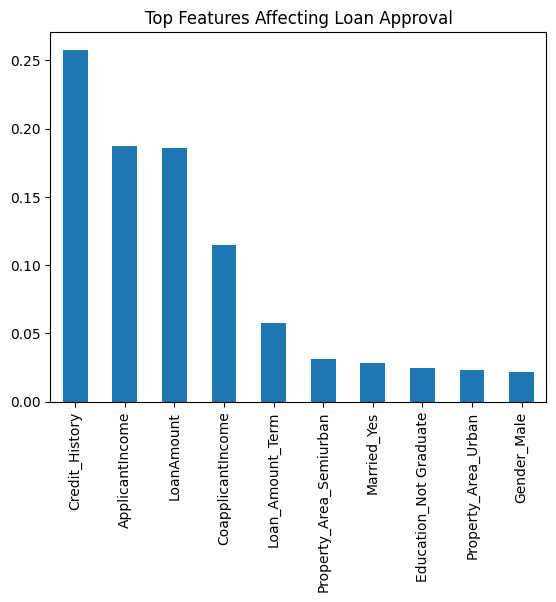

In [83]:
importance = pd.Series(pipeline.named_steps['model'].feature_importances_, index=X_train.columns).sort_values(ascending=False)
importance.head(10).plot(kind="bar")
plt.title("Top Features Affecting Loan Approval")
plt.show()

In [84]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [88]:
results = X_test.copy()
results["actual_loan_status"] = y_test.values
results["approval_probability"] = y_prob
results["approval_score"] = (results["approval_probability"] * 100).round(2)

In [89]:
def approval_band(prob):
  if prob >= 0.75:
    return "Highly Likely Approved"
  elif prob >= 0.50:
    return "Moderately Likely Approved"
  else:
    return "Low Approval Chance"

In [90]:
results["approval_band"] = results["approval_probability"].apply(approval_band)

In [91]:
def approval_decision(prob):
    if prob >= 0.75:
        return "Approve"
    elif prob >= 0.50:
        return "Manual Review"
    else:
        return "Reject"

In [92]:
results["decision"] = results["approval_probability"].apply(approval_decision)

In [93]:
results.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,actual_loan_status,approval_probability,approval_score,approval_band,decision
350,9083,0.0,228.0,360.0,1.000000,True,True,False,False,False,False,False,True,False,True,0.810,81.0,Highly Likely Approved,Approve
377,4310,0.0,130.0,360.0,0.842199,True,True,False,False,False,False,False,True,False,True,0.820,82.0,Highly Likely Approved,Approve
163,4167,1447.0,158.0,360.0,1.000000,True,True,False,True,False,False,False,False,False,True,0.755,75.5,Highly Likely Approved,Approve
609,2900,0.0,71.0,360.0,1.000000,False,False,False,False,False,False,False,False,False,True,0.620,62.0,Moderately Likely Approved,Manual Review
132,2718,0.0,70.0,360.0,1.000000,True,False,False,False,False,False,False,True,False,True,0.930,93.0,Highly Likely Approved,Approve


In [95]:
summary = results.groupby("approval_band").agg(
    applications=("approval_band", "count"),
    avg_score=("approval_score", "mean"),
    actual_approval_rate=("actual_loan_status", "mean")
).reset_index()

In [96]:
summary

,approval_band,applications,avg_score,actual_approval_rate
0,Highly Likely Approved,68,86.338235,0.779412
1,Low Approval Chance,20,20.575000,0.100000
2,Moderately Likely Approved,35,66.757143,0.714286


In [97]:
results.to_csv("loan_approval_predictions.csv", index=False)

In [98]:
results.to_csv("loan_approval_predictions.csv", index=False)

In [99]:
dashboard_data = results.copy()

In [100]:
dashboard_data.to_csv("loan_approval_dashboard_data.csv", index=False)

In [102]:
import sqlite3
conn = sqlite3.connect("loan_approval_pipeline.db")

In [103]:
summary.to_csv("loan_approval_summary.csv", index=False)

In [104]:
df.to_sql("processed_loan_data", conn, if_exists="replace", index=False)

614

In [105]:
results.to_sql("loan_approval_results", conn, if_exists="replace", index=False)

123

In [107]:
summary.to_sql("loan_approval_summary", conn, if_exists="replace", index=False)

3

In [108]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,processed_loan_data
1,loan_approval_results
2,loan_approval_summary


In [109]:
query ="""
SELECT approval_band, COUNT(*) AS total_applications
FROM loan_approval_results
GROUP BY approval_band
ORDER BY total_applications DESC;
"""

In [110]:
pd.read_sql(query, conn)

,approval_band,total_applications
0,Highly Likely Approved,68
1,Moderately Likely Approved,35
2,Low Approval Chance,20


In [111]:
query = """
SELECT decision, COUNT(*) AS total_cases
FROM loan_approval_results
GROUP BY decision
ORDER BY total_cases DESC;
"""

In [112]:
pd.read_sql(query,conn)

,decision,total_cases
0,Approve,68
1,Manual Review,35
2,Reject,20


In [113]:
query = """
SELECT decision, COUNT(*) AS total_cases
FROM loan_approval_results
GROUP BY decision
ORDER BY total_cases DESC;
"""

In [114]:
pd.read_sql(query, conn)

,decision,total_cases
0,Approve,68
1,Manual Review,35
2,Reject,20


In [115]:
conn.close()